In [49]:
import torch
from torch.utils.data import DataLoader
import clip
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import umap
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [37]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Detected device: {device.upper()}")

Detected device: CPU


In [38]:
model, preprocess = clip.load("ViT-B/32", device=device)

In [39]:
import torchvision
from torchvision import datasets, transforms
import numpy as np
from collections import defaultdict

# Download and load CIFAR-10 dataset
cifar10_train = datasets.CIFAR10(root='./data', train=True, download=True)
cifar10_test = datasets.CIFAR10(root='./data', train=False, download=True)


print(f"CIFAR-10 Train set size: {len(cifar10_train)}")
print(f"CIFAR-10 Test set size: {len(cifar10_test)}")
print(f"Classes: {cifar10_train.class_to_idx}")

CIFAR-10 Train set size: 50000
CIFAR-10 Test set size: 10000
Classes: {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


In [40]:
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                   'dog', 'frog', 'horse', 'ship', 'truck']


print("Przygotowywanie wektorów tekstu (text features)...")
text_prompts = [f"A photo of a {class_name}" for class_name in cifar10_classes]
text_inputs = torch.cat([clip.tokenize(prompt) for prompt in text_prompts]).to(device)

Przygotowywanie wektorów tekstu (text features)...


In [ ]:
cifar10 = cifar10_test # używamy zbioru testowego do ewaluacji

with torch.no_grad():
    text_features = model.encode_text(text_inputs)
    text_features /= text_features.norm(dim=-1, keepdim=True)

def collate_fn(batch):
    # batch to lista krotek: [(PIL_image, label), (PIL_image, label), ...]
    images = torch.stack([preprocess(item[0]) for item in batch])
    labels = torch.tensor([item[1] for item in batch])
    return images, labels

batch_size = 256
dataloader = DataLoader(cifar10, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

correct_per_class = {classname: 0 for classname in cifar10.classes}
total_per_class = {classname: 0 for classname in cifar10.classes}
correct_total = 0

all_image_features = []
all_labels = []

print("Trwa sprawdzanie obrazów (wersja batchowa)...")
with torch.no_grad():
    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)
        
        image_features = model.encode_image(images)
        image_features /= image_features.norm(dim=-1, keepdim=True)

        all_image_features.append(image_features.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
        
        predicted_classes = similarity.argmax(dim=-1)
        
        for i in range(len(labels)):
            true_label = labels[i].item()
            pred_label = predicted_classes[i].item()
            classname = cifar10.classes[true_label]
            
            total_per_class[classname] += 1
            
            if pred_label == true_label:
                correct_per_class[classname] += 1
                correct_total += 1

print("\n--- WYNIKI DLA KAŻDEJ KLASY ---")
for classname in cifar10.classes:
    accuracy = 100 * correct_per_class[classname] / max(total_per_class[classname], 1)
    print(f"{classname:<12}: {accuracy:>5.2f}%")

total_accuracy = 100 * correct_total / len(cifar10)
print("-" * 25)
print(f"Ogółem      : {total_accuracy:>5.2f}%")

Trwa sprawdzanie obrazów (wersja batchowa)...


100%|██████████| 40/40 [02:07<00:00,  3.19s/it]


--- WYNIKI DLA KAŻDEJ KLASY ---
airplane    : 90.10%
automobile  : 97.60%
bird        : 88.80%
cat         : 86.00%
deer        : 76.50%
dog         : 88.40%
frog        : 77.40%
horse       : 97.60%
ship        : 95.50%
truck       : 90.10%
-------------------------
Ogółem      : 88.80%


Łączenie zebranych wektorów...
Uruchamianie PCA dla obrazów...
Uruchamianie UMAP dla obrazów (to może chwilę potrwać)...


/Users/bilskik/.pyenv/versions/magistrala/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Rzutowanie embeddingów tekstowych UMAP...
Generowanie wykresów...


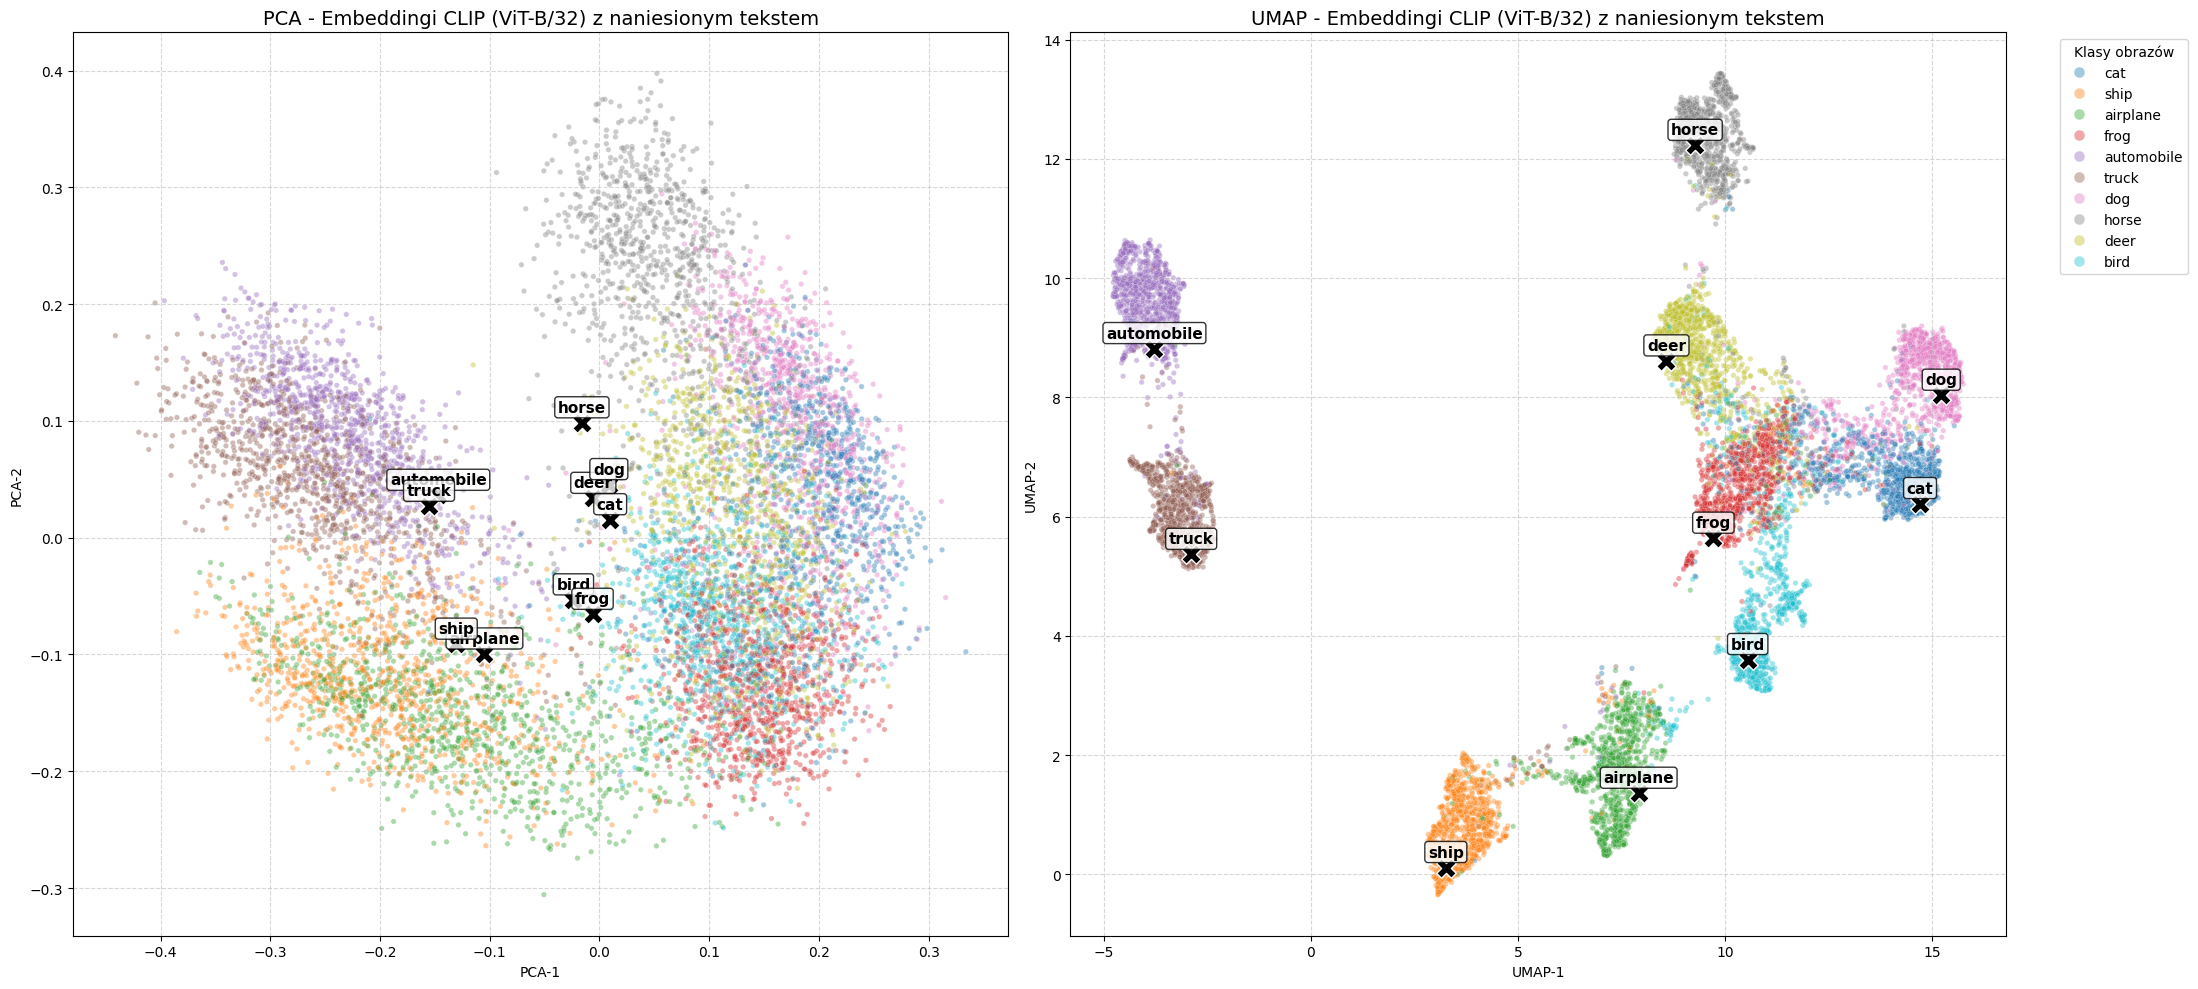

In [ ]:
# --- ANALIZA EMBEDDINGÓW (PCA & UMAP) ---

print("Łączenie zebranych wektorów...")
features_np = np.concatenate(all_image_features, axis=0)
labels_np = np.concatenate(all_labels, axis=0)
label_names = [cifar10.classes[idx] for idx in labels_np]

text_features_np = text_features.cpu().numpy()

print("Uruchamianie PCA dla obrazów...")
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(features_np)

text_pca = pca.transform(text_features_np)

print("Uruchamianie UMAP dla obrazów (to może chwilę potrwać)...")
umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_results = umap_reducer.fit_transform(features_np)

print("Rzutowanie embeddingów tekstowych UMAP...")
text_umap = umap_reducer.transform(text_features_np)

df_viz = pd.DataFrame({
    'PCA-1': pca_results[:, 0],
    'PCA-2': pca_results[:, 1],
    'UMAP-1': umap_results[:, 0],
    'UMAP-2': umap_results[:, 1],
    'Klasa': label_names
})

print("Generowanie wykresów...")
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# --- WYKRES PCA ---
sns.scatterplot(
    x='PCA-1', y='PCA-2',
    hue='Klasa',
    palette='tab10',
    data=df_viz,
    ax=axes[0],
    alpha=0.4,
    s=15
)
axes[0].set_title('PCA - Embeddingi CLIP (ViT-B/32) z naniesionym tekstem', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.5)

for i, classname in enumerate(cifar10.classes):
    axes[0].scatter(text_pca[i, 0], text_pca[i, 1], marker='X', s=200, color='black', edgecolors='white', zorder=5)
    axes[0].annotate(classname, (text_pca[i, 0], text_pca[i, 1]), 
                     xytext=(0, 8), textcoords='offset points', ha='center',
                     fontsize=11, fontweight='bold', color='black', zorder=6,
                     bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", lw=1, alpha=0.8))

sns.scatterplot(
    x='UMAP-1', y='UMAP-2',
    hue='Klasa',
    palette='tab10',
    data=df_viz,
    ax=axes[1],
    alpha=0.4,
    s=15
)
axes[1].set_title('UMAP - Embeddingi CLIP (ViT-B/32) z naniesionym tekstem', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.5)

for i, classname in enumerate(cifar10.classes):
    axes[1].scatter(text_umap[i, 0], text_umap[i, 1], marker='X', s=200, color='black', edgecolors='white', zorder=5)
    axes[1].annotate(classname, (text_umap[i, 0], text_umap[i, 1]), 
                     xytext=(0, 8), textcoords='offset points', ha='center',
                     fontsize=11, fontweight='bold', color='black', zorder=6,
                     bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", lw=1, alpha=0.8))

axes[0].get_legend().remove()
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Klasy obrazów", markerscale=2)

plt.tight_layout()
plt.show()